In [113]:
import numpy as np
from veripulse.pulse import run_grape_si, run_grape, PulseConfig, print_pulse_config
from veripulse.gates import rx, rhox, pack_subspace_states, extract_subspace_states, Qobj, operator_to_vector, vector_to_operator
from veripulse.sdp import choi_optimise_secret_indep, calc_secret_indep

import matplotlib.pyplot as plt
%matplotlib inline

# Configurations and target states

In [3]:
conf1 = PulseConfig() # masukan goal 
print_pulse_config(conf1)

Parameter                      Value Description
─────────────────────────────────────────────
omega_drift                1.000e+07  Hz
T2_star                    2.000e-06  s
drive_error                3.000e-02  
detuning                   0.000e+00  normalised
evo_time                   3.000e-07  s
num_tslots                       100  
amp_lbound                -1.000e+00  
amp_ubound                 1.000e+00  
fid_err_targ               1.000e-08  
max_iter                        1000  
max_wall_time              1.200e+02  s
init_pulse_type                  RND  
fid_params                        {}  


In [4]:
# number of states 
K = 8 
# initial states with a little noise 
err= 1e-3
rho_init = Qobj([[1-err,0],[0,err]])
# target states 
rho_targets = [Qobj(rhox(i*np.pi/4)) for i in range(K)]

In [5]:
rho_init

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.999 0.   ]
 [0.    0.001]]

# 1 Regular GRAPE

In [32]:
# GRAPE optimisation part
result1 = []
for rho_targ in rho_targets:
    res = run_grape(operator_to_vector(rho_init), operator_to_vector(rho_targ), config=PulseConfig(fid_err_targ=1e-10, max_iter=10000000, max_wall_time=10000))
    result1.append(res)

In [33]:
# Check optimisation results
for res in result1:
    print("fid err:",res.fid_err)

fid err: 4.495812754916373e-06
fid err: 2.802668760017201e-06
fid err: 1.2103170505366949e-05
fid err: 2.6781578880144818e-05
fid err: 9.664917386912076e-06
fid err: 1.3320034700995217e-05
fid err: 2.7444876300735134e-05
fid err: 6.699773907457851e-06


**Calculate secret independence**

In [34]:
# state formatting
rho_fin_res1 = [vector_to_operator(res.evo_full_final).full() for res in result1]
rho_targ_np = [rho.full() for rho in rho_targets] 

In [35]:
res1_si = choi_optimise_secret_indep(rho_targ_np, rho_fin_res1)

In [36]:
res1_si.objective

np.float64(0.001589892549004044)

# 2 GRAPE with noise averaging methode

In [13]:
# packing states 
K = 8
vRho_init, vRho_target, U_big = pack_subspace_states(
    rotations=[rx(j * np.pi / 4) for j in range(K)],
    rho_init=rho_init,
)

In [15]:
conf2 = PulseConfig(fid_err_targ=1e-10, max_iter=10000000, max_wall_time=10000)
print_pulse_config(conf2)

Parameter                      Value Description
─────────────────────────────────────────────
omega_drift                1.000e+07  Hz
T2_star                    2.000e-06  s
drive_error                3.000e-02  
detuning                   0.000e+00  normalised
evo_time                   3.000e-07  s
num_tslots                       100  
amp_lbound                -1.000e+00  
amp_ubound                 1.000e+00  
fid_err_targ               1.000e-10  
max_iter                    10000000  
max_wall_time                  10000  s
init_pulse_type                  RND  
fid_params                        {}  


In [17]:
result2 = run_grape_si(vRho_init, vRho_target, U_big, lam=0.01, config=conf2)

Secret Independence =  0.38389255729967864
fidelity error =  0.00023445837308291184
Secret Independence =  0.38361245586996173
fidelity error =  0.00023448495736594008
Secret Independence =  0.38333172084593914
fidelity error =  0.00023451165474272745
Secret Independence =  0.3822057471434125
fidelity error =  0.00023461791487083182
Secret Independence =  0.3782104961145355
fidelity error =  0.0002349847096143299
Secret Independence =  0.37791869578216347
fidelity error =  0.0002350135330154727
Secret Independence =  0.3767485183897127
fidelity error =  0.0002351282694342632
Secret Independence =  0.37202190075681896
fidelity error =  0.00023557830468913228
Secret Independence =  0.3643182069983484
fidelity error =  0.00023626883271585654
Secret Independence =  0.3639994085464732
fidelity error =  0.00023630276104429575
Secret Independence =  0.3627214088545284
fidelity error =  0.00023643781020535838
Secret Independence =  0.35756655156916073
fidelity error =  0.00023696738160706055
S

In [21]:
rho_fin_res2=extract_subspace_states(result2, K)

In [41]:
solver_opts = {"verbose": False, "eps": 1e-10, "max_iters": 10000}
res2_si = choi_optimise_secret_indep(rho_targ_np, rho_fin_res2, solver_opts=solver_opts)

In [67]:
res2_si.objective

np.float64(0.0025797196397621797)

In [43]:
res2_si.status

'optimal'

## split states

In [62]:
conf2 = PulseConfig(fid_err_targ=1e-12, max_iter=10000000, max_wall_time=10000)
print_pulse_config(conf2)

Parameter                      Value Description
─────────────────────────────────────────────
omega_drift                1.000e+07  Hz
T2_star                    2.000e-06  s
drive_error                3.000e-02  
detuning                   0.000e+00  normalised
evo_time                   3.000e-07  s
num_tslots                       100  
amp_lbound                -1.000e+00  
amp_ubound                 1.000e+00  
fid_err_targ               1.000e-12  
max_iter                    10000000  
max_wall_time                  10000  s
init_pulse_type                  RND  
fid_params                        {}  


In [37]:
# packing states 
angles_pair = [(0, np.pi), (np.pi/4, 5*np.pi/4), (np.pi/2, 3*np.pi/2), (3*np.pi/4, 7*np.pi/4)]

In [39]:
vRho_init, vRho_target, U_big = pack_subspace_states(
    rotations=[rx(t[0]) for t in angles_pair],
    rho_init=rho_init,
)

In [63]:
res_split1 = run_grape_si(vRho_init, vRho_target, U_big, lam=100, config=conf2)

Secret Independence =  0.2907260291778432
fidelity error =  0.001162489455540994
Secret Independence =  0.3808082587051311
fidelity error =  0.0011364690052956899
Secret Independence =  0.2938603265509442
fidelity error =  0.0017868240474252668
Secret Independence =  0.4332515102390876
fidelity error =  0.0015396416444126285
Secret Independence =  0.038139145981626904
fidelity error =  0.0006546710000927588
Secret Independence =  0.21584044930480295
fidelity error =  0.0008882303636664094
Secret Independence =  0.0028358164852176314
fidelity error =  0.0006044819984815867
Secret Independence =  0.0001018076649514982
fidelity error =  0.0006043287174120713
Secret Independence =  3.1533856284139085e-05
fidelity error =  0.0006037169188356784
Secret Independence =  2.9748007089360356e-05
fidelity error =  0.0006036925834730809
Secret Independence =  2.9714841848701905e-05
fidelity error =  0.0006036609654406958
Secret Independence =  2.968070182071863e-05
fidelity error =  0.0006035897569

In [123]:
rtarg=[rhox(t[0]) for t in angles_pair]
rfin=extract_subspace_states(res_split1, 4)
solver_opts = {"verbose": False, "eps": 1e-12, "max_iters": 10000}
si_split1 = choi_optimise_secret_indep(rtarg, rfin,solver_opts = solver_opts)

In [124]:
si_split1.objective

np.float64(9.280126890666683e-06)

In [126]:
calc_secret_indep(si_split1.choi, rtarg, rfin)

np.float64(9.280127009789612e-06)

In [114]:
def plot_pulse(result):
    final_fidelity_error = result.fid_err
    fig1 = plt.figure()
    ax = fig1.add_subplot(2, 1, 2)
    ax.set_title(f"Optimized Control Sequences: fid_err = {final_fidelity_error:.8e}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Control amplitude")
    ax.step(
        result.time,
        np.hstack((result.final_amps[:, 0], result.final_amps[-1, 0])),
        where="post",
    )
    plt.tight_layout()
    plt.show()

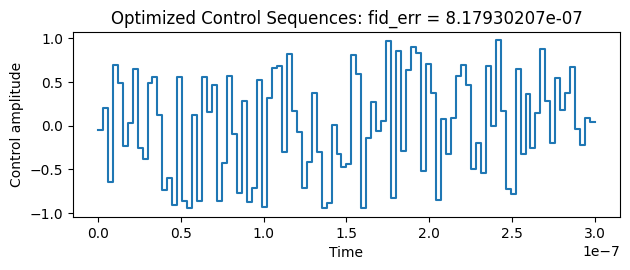

In [115]:
plot_pulse(res_split1)

In [116]:
res_split1.wall_time

356.58706297399476